# Clustering Algorithms without sklearn

**Learning Outcomes**
1. Implement K-means algorithms and its variant from scratch using numpy
2. Understand the details of writing an algorithm gradually in a step by step manner
3. Understand how each step of K-means contributes to a convergence behaviour

In this exercise, we will implement K-means algorithm from scratch. You will be able to see first-hand how the algorithm is built in a simple and effective way. There are other implementations, we have chosen this one to expose the inner mechanisms and principles of clustering algorithms.


## K-Means for Binary Cluters

In [3]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


### Generate the data

In [4]:
# generate the data
def generatC12(n  = 50, spread=2):
    mu1, cov1 = [5, 5], [[.5*spread, 0], [0, .5*spread]]
    mu2, cov2 = [9, 5], [[.5*spread, 0], [0, .5*spread]]

    N  = n
    N1 = N
    N2 = N

    C1 = np.round(np.random.multivariate_normal(mu1,cov1,N1),1)  # Cluster 1 in 2d
    C2 = np.round(np.random.multivariate_normal(mu2,cov2,N2),1)  # Cluster 2 in 2d
    C12 = np.concatenate((C1,C2),0) # combine both clusters together no labels are provided 
                                    #this is unsupervised learning

    c1 = np.average(C1,0)        # centroid of C1
    c2 = np.average(C2,0)        # centroid of C2
    return C1, C2, c1, c2, C12   # the generated data put pairs on the columns to make plotting easy


### Helper Functions

In [5]:
a = [[0,1], [1,2], [2,3]]
a = np.array(a)
print(a)
print(a.T[0])

[[0 1]
 [1 2]
 [2 3]]
[0 1 2]


In [6]:
def plotC(C, colourshape='bo', c=[]):
    C = C.T
    plt.plot(C[0], C[1], colourshape, markersize=10, mfc='none')
    
    if len(c) != 0:
         plt.plot(c[0], c[1],  '+', markersize=25)
    plt.xlim([0, 11])
    plt.ylim([0, 11])

def plotC12(C1, C2, c1, c2):
    #print(c1.shape)
    plotC(C1, 'g^', c1)
    #print(c2.shape)
    plotC(C2, 'yo', c2)

def saveC(C):
    #save in panda dataframe
    Cf = pd.DataFrame(C,columns=['x1','x2'])     # we want the data to be tabular   
    plt.savefig('../figures/SimpleBinaryClusters.png')
    Cf.to_csv ('../datasets/SimpleBinaryClusters.csv',index=False)

In [69]:
# now we calculate the distance between each centroid and the rest of the dataset, 
# we can use broadcasting which is great to guarantee efficiency of running the algorithm
# c1_ ,  c2_ = c1 - 1.5,  c2 + 2.5
# c1_ ,  c2_ = c1 + 1.5,  c2 - 2.5

def getClusters(C12, c1, c2):
    dist1 = np.sqrt(np.sum((c1 - C12)**2,1))   # note how we utilise broadcasting
    dist2 = np.sqrt(np.sum((c2 - C12)**2,1))   # note how we utilise broadcasting
    min_dist = np.minimum(dist1,dist2)         # this returns an array of min distances
    
    C1_ind   = np.where(dist1==min_dist)
    C2_ind   = np.where(dist2==min_dist)

    C1       = C12[C1_ind]
    C2       = C12[C2_ind]

    plotC(C1, 'g^', c1)
    plotC(C2, 'yo', c2)    
    
    return C1, C2

### Retrieve the Centroids

In [70]:
def getCentroids(C1, C2):
    c1 = np.average(C1,0)        # centroid of C1
    c2 = np.average(C2,0)        # centroid of C2
    print(c1)
    print(c2)
    return c1, c2

### K-means Implementation
Now we are in a position to be able to implement the K-means algorithm

In [61]:
def kmeans(C12, c1, c2, save=True):
    c1,  c2 =  c1,  c2
    
    #while True:
    for i in range(10):
        print(f'Running iteration: {i+1}')
        C1,  C2  = getClusters (C12, c1, c2)
        c1_, c2_ = getCentroids(C1,  C2)
                
        if save==True:            plt.savefig('../figures/SimpleBinaryClusters{}.png'.format(i))
            
        if (c1_== c1).all() and (c2_== c2).all(): break   # early stopping condition
        else: c1, c2 = c1_, c2_
        
        plt.pause(1) # comment this out in order to make the algorihtm fast, it is placed to visualise different steps
    #print(f'Centroids found! c1 = {c1}; c2 = {c2}')

(100, 2)


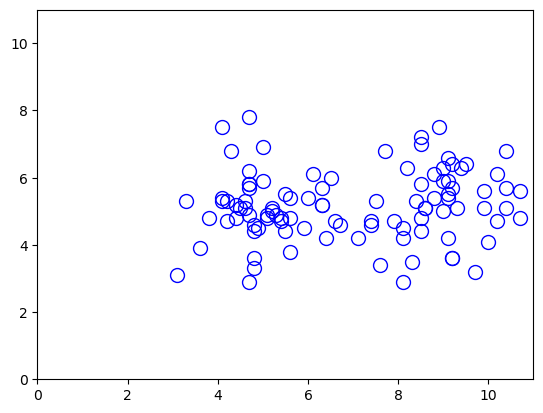

In [25]:
#C1__, C2__, c1__, c2__, C12__ = C1, C2, c1, c2, C12   # to store a  instance that we like
C1, C2, c1, c2, C12 = generatC12()                    # uncoment to regenerate
print(C12.shape)
#plotC12(C1, C2, c1, c2)
plotC(C12)
saveC(C12)

Plot the data

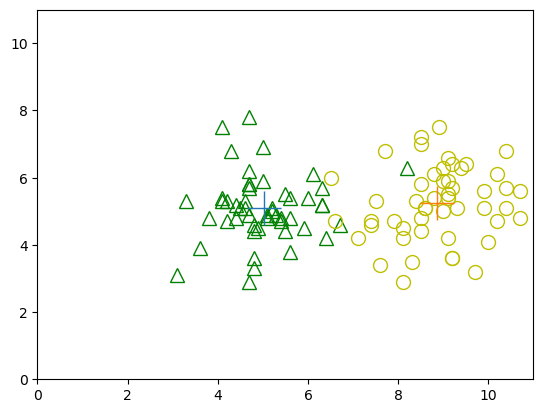

In [26]:
plotC12(C1, C2, c1, c2)
plt.savefig('../figures/SimpleBinaryClustersSolution.png')

Running iteration: 1
[4.56 7.04]
[7.06421053 5.07263158]


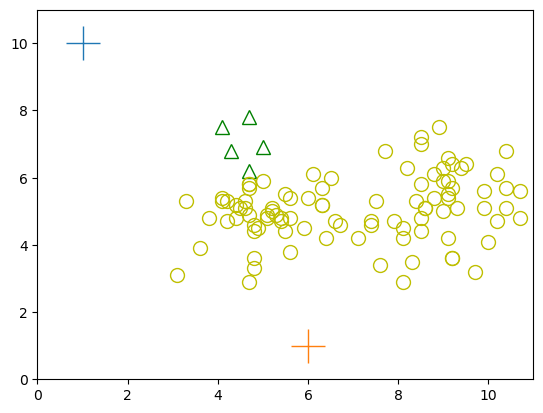

Running iteration: 2
[4.32608696 5.50434783]
[7.71948052 5.07142857]


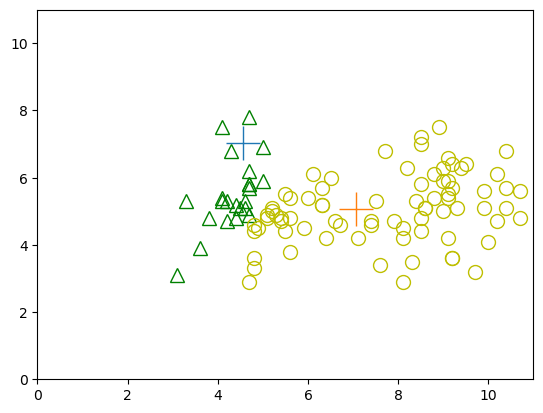

Running iteration: 3
[4.79090909 5.09090909]
[8.62678571 5.23392857]


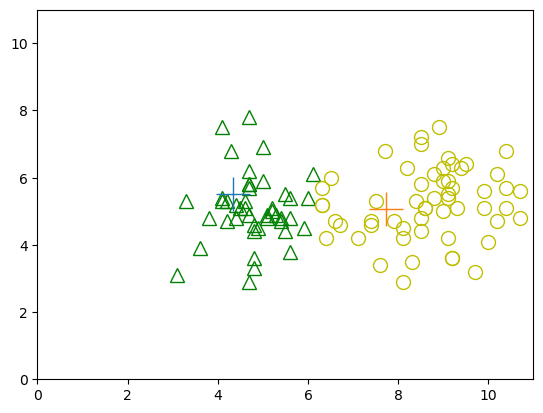

Running iteration: 4
[5.01764706 5.09019608]
[8.93877551 5.25510204]


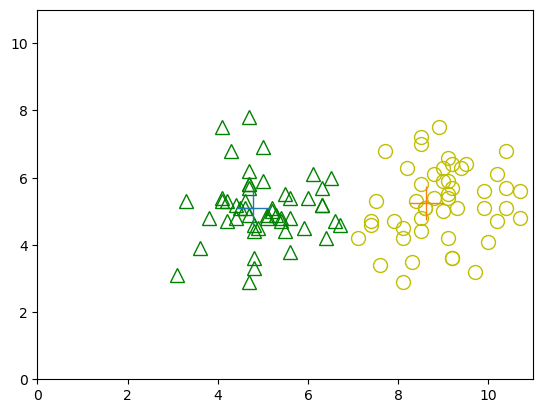

Running iteration: 5
[5.01764706 5.09019608]
[8.93877551 5.25510204]
Centroids found! c1 = [5.01764706 5.09019608]; c2 = [8.93877551 5.25510204]


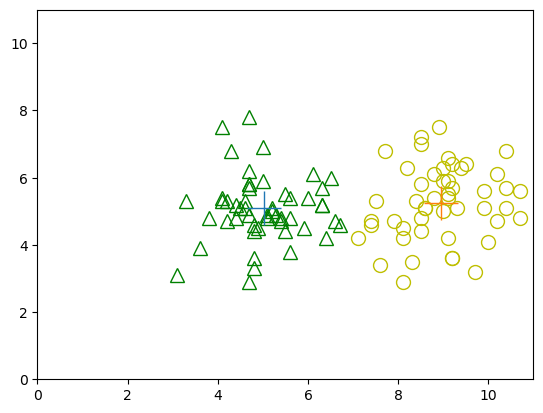

In [73]:
#c1, c2 = [6,3], [1,10]  # try this and se how this centroid initialisation can lead to infinitely loop we address this problem in k-means++
#c1, c2 = [6,2], [1,10]  # also does not work

c1, c2 = [6,1], [1,10]

kmeans(C12, c2, c1 )

## K-Means for K number of Clusters

Try adapting the above code for multiple clusters

### Your Turn: Mini-Batch K-means ++

Now it is your turn to *try* to implement the mini-batch K-means. It is almost identical to the K-means, the main difference is that we partition the dataset into several chunks with the same size and then we use one after the other to update the centroids and the clusters. See the content algorithm.

In [71]:
def kmeansMB(C12, c1, save=True):
    k = 4 #number of chunks / samples
    iter_stop = 10 #max number of times to attempt
    batch_size = (int(C12.shape[0]/k), C12.shape[1])
    
    # Calculate probabilities to choose next centroid
    dist_to_c1 = np.sqrt(np.sum((c1 - C12)**2,1)) # Distance of each instance to c1
    prob_c2 = dist_to_c1 / sum(dist_to_c1) # Probability of each instance for being chosen as c2
    
    # Choosing C2 centroid
    c2_index = np.random.choice(np.arange(len(C12)), size=1, p=prob_c2) # Randomly choosing one C12 value
    c2 = C12[c2_index][0]

    #while True:
    for i in range(iter_stop):
        print(f'Iteration: {i+1}')
        batch = np.random.choice(C12.flatten(), size=(batch_size)) # Creating random batch
        
        C1,  C2  = getClusters (batch, c1, c2)
        
        c1_ = ((i*batch_size[0]*c1) + np.sum(C1))/ ((i+1)*batch_size[0]) # Calculating new c1
        c2_ = ((i*batch_size[0]*c2) + np.sum(C2))/ ((i+1)*batch_size[0]) # Calculating new c2
        

        if save==True:            plt.savefig('../figures/SimpleBinaryClusters{}.png'.format(i))

        if (c1_== c1).all() and (c2_== c2).all(): break   # early stopping condition
        else: 
            c1, c2 = c1_, c2_
            print(c1)
            print(c2)

        plt.pause(1)
    print('Mini-batch centroids found...')
    print('Running Kmeans to refine..')
    
    kmeans(C12, c1, c2)

Iteration: 1
[0.672 0.672]
[11.084 11.084]


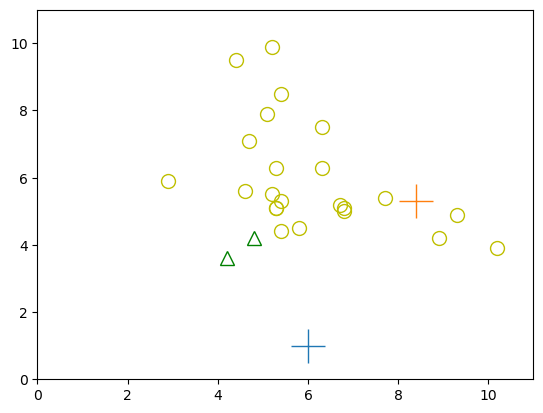

Iteration: 2
[2.748 2.748]
[9.368 9.368]


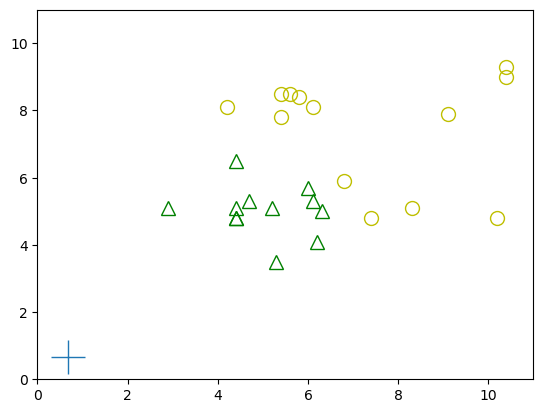

Iteration: 3
[3.38933333 3.38933333]
[8.73466667 8.73466667]


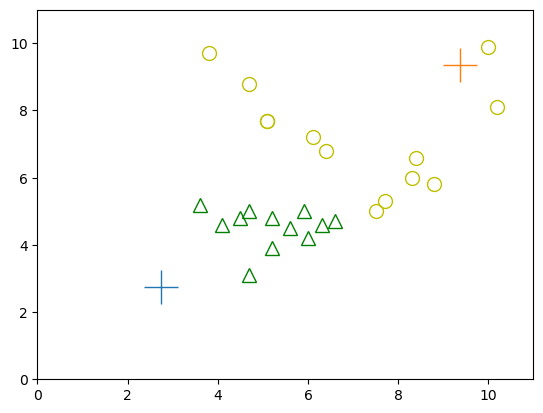

Iteration: 4
[3.756 3.756]
[8.416 8.416]


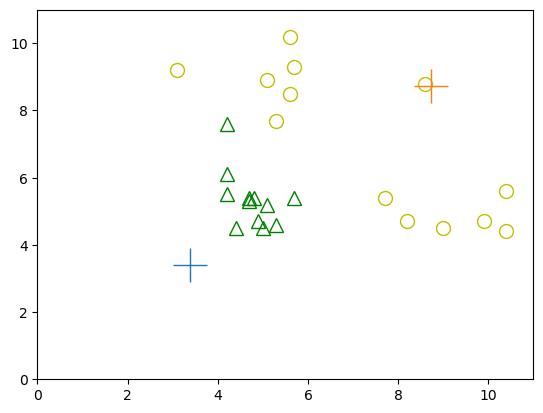

Iteration: 5
[4.0136 4.0136]
[8.1928 8.1928]


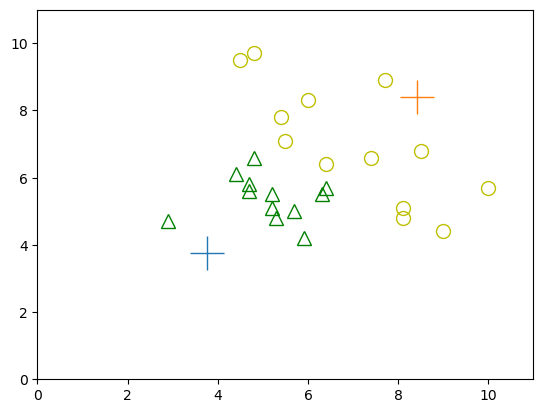

Iteration: 6
[4.294 4.294]
[7.884 7.884]


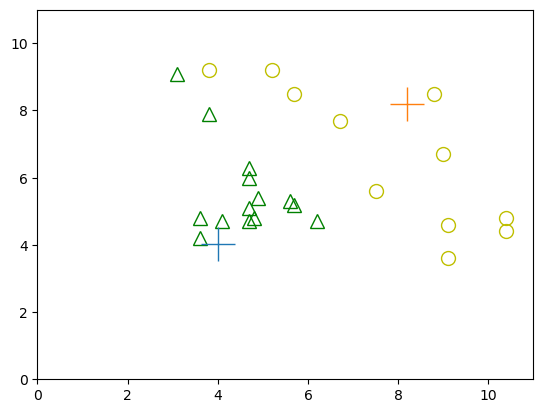

Iteration: 7
[4.68971429 4.68971429]
[7.37428571 7.37428571]


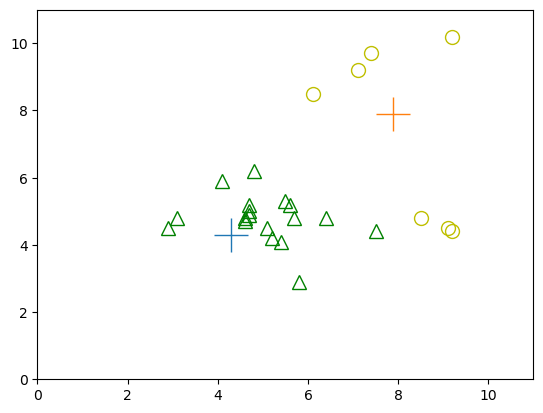

Iteration: 8
[4.9515 4.9515]
[7.0215 7.0215]


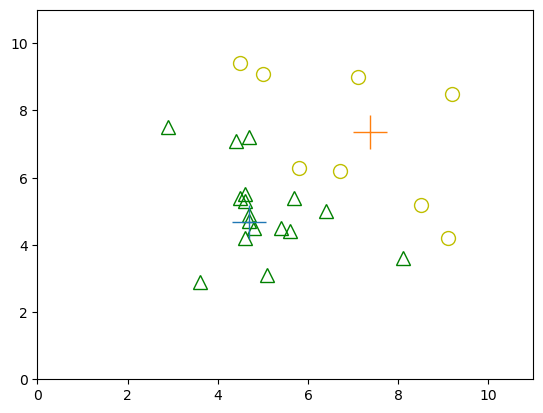

Iteration: 9
[4.95422222 4.95422222]
[7.07288889 7.07288889]


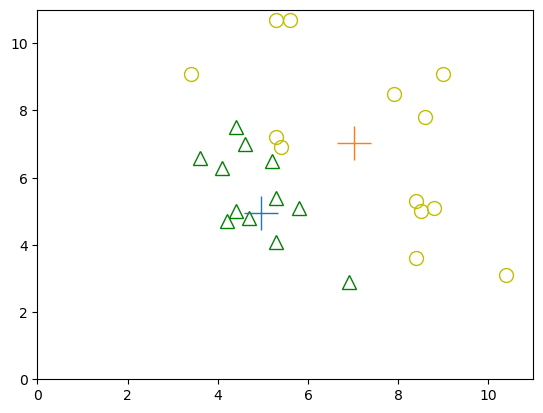

Iteration: 10
[5.0408 5.0408]
[6.9648 6.9648]


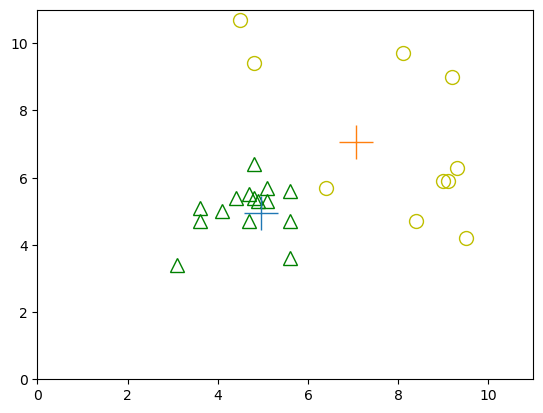

Mini-batch centroids found...
Running Kmeans to refine..
Running iteration: 1
[5.22830189 4.87358491]
[8.86808511 5.50638298]


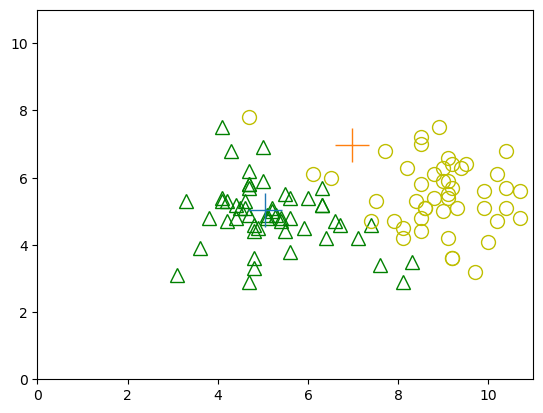

Running iteration: 2
[5.05769231 5.07307692]
[8.97708333 5.27708333]


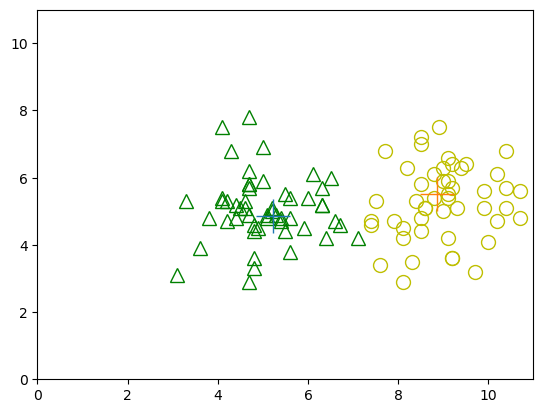

Running iteration: 3
[5.01764706 5.09019608]
[8.93877551 5.25510204]


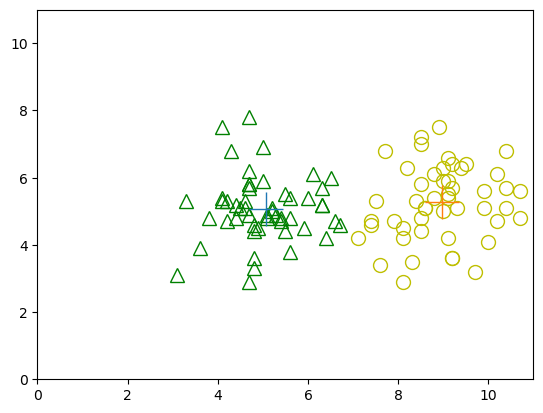

Running iteration: 4
[5.01764706 5.09019608]
[8.93877551 5.25510204]
Centroids found! c1 = [5.01764706 5.09019608]; c2 = [8.93877551 5.25510204]


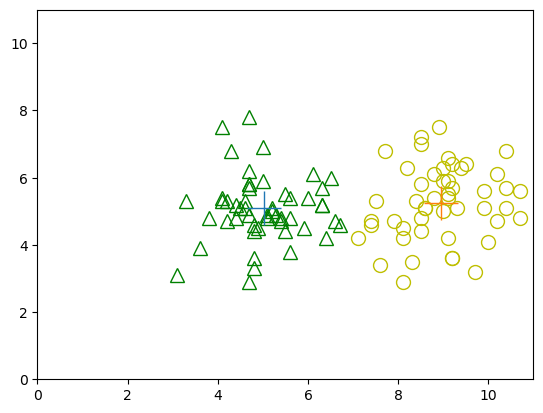

In [72]:
c1 = np.array([6,1])
kmeansMB(C12, c1, save=True)